# LSTAR panel — **PARK**

**Paper:** §3.2 LSTAR / logistic smooth transition (PDF pp. 16–20; Eqs 4–7) · **NOTES:** [`NOTES.md`](NOTES.md)  
**Status:** `park` — γ / c unidentified on short crypto day-panel; full GMM + FE not attempted.

Paper transition:

$$G(z_{t-1}) = \frac{1}{1+\exp(-\gamma(z_{t-1}-c))}$$

Desk keeps `cdme.logistic_G` as a continuous constrained weight for monitors, not a Promote path.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


## Why parked


In [2]:

dcm_panel = load_json(OUT / "dcm_proxies" / "panel_rows.json") or []
hourly = expand_dcm_hourly(dcm_panel)
n_days = hourly["day"].nunique() if len(hourly) else 0
n_finite = int(np.isfinite(hourly.get("dcm", pd.Series(dtype=float))).sum()) if len(hourly) else 0
print(f"usable DCM hours={n_finite} across {n_days} days — far below paper's multi-year FX panel")
print("Park reasons: (1) short tape (2) no triplet FE design (3) γ/c NLS unidentified (4) funding proxy ≠ bank DCM")


usable DCM hours=111 across 9 days — far below paper's multi-year FX panel
Park reasons: (1) short tape (2) no triplet FE design (3) γ/c NLS unidentified (4) funding proxy ≠ bank DCM


## Toy / illustrative — logistic G on synthetic + observed DCM̂


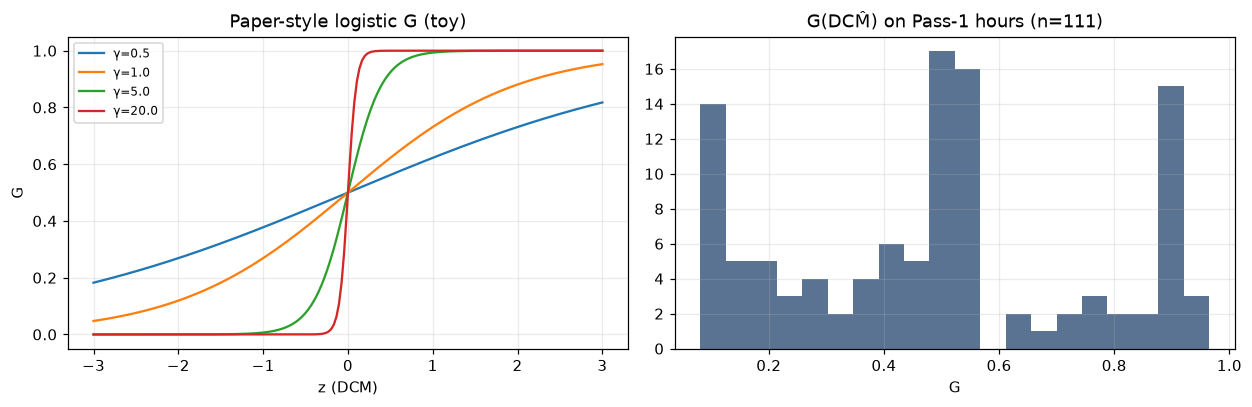

In [3]:

z = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]
for g in (0.5, 1.0, 5.0, 20.0):
    ax.plot(z, cdme.logistic_G(z, gamma=g, c=0.0), label=f"γ={g}")
ax.set_xlabel("z (DCM)"); ax.set_ylabel("G"); ax.set_title("Paper-style logistic G (toy)")
ax.legend(fontsize=8)

ax = axes[1]
d = hourly["dcm"].to_numpy(dtype=float) if len(hourly) else np.array([])
finite = d[np.isfinite(d)]
if finite.size:
    G = cdme.logistic_G(finite, gamma=1.0)
    ax.hist(G, bins=20, color="#3d5a80", alpha=0.85)
    ax.set_title(f"G(DCM̂) on Pass-1 hours (n={finite.size})")
    ax.set_xlabel("G")
else:
    ax.text(0.5, 0.5, "no DCM hours", ha="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()


## Signal board


In [4]:

print_board([
    ("disc.lstar_gmm", "Park", "γ/c + FE unidentified on short tape — do not Promote"),
    ("risk.dcm_pc1", "Hold", "logistic_G helper OK for monitor weight only"),
])
print("Falsifier status: N/A while parked; re-open if multi-month panel + real funding arrives")


id                                 gate   note
----------------------------------------------------------------------------------------
disc.lstar_gmm                     Park   γ/c + FE unidentified on short tape — do not Promote
risk.dcm_pc1                       Hold   logistic_G helper OK for monitor weight only
Falsifier status: N/A while parked; re-open if multi-month panel + real funding arrives
